In [3]:
import sys 
print(sys.executable)

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression

c:\Users\benja\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
df = pd.read_excel('2019-2026.xlsx')

display(df)

,Donation Date (UTC),Intended Donation,Amount Charged,First Name,Last Name,Email,Address,City,State,Zipcode,Phone,Campaign,Comment
0,2019-03-14,100.0,100.00,Bruce,Boyea,noemail+59@123.com,NaN,NaN,NaN,NaN,NaN,NaN,"In Memory of Christopher Demtrak, MD"
1,2019-03-15,200.0,208.90,Lee Ann,Simonis,lsimonis@keyscomp.com,NaN,NaN,NaN,NaN,NaN,Captain & Crew Golf Tournament,NaN
2,2019-03-18,100.0,100.00,Paul & Nicole,Huff,noemail+206@123.com,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
3,2019-04-06,100.0,104.60,Denise,Barry,dbarry3@partners.org,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
4,2019-06-10,650.0,650.00,George,Scherer,gschere1@aol.com,9 Pamela Dr,Binghamton,New York,13901,607-648-8308,Captain & Crew Golf Tournament,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,2025-12-29,500.0,532.00,Leah,Cunningham,cunninghaml@me.com,NaN,NaN,NaN,13903,NaN,Boys & Girls Club of Binghamton Great Futures ...,In memory of Dr. Pejo
749,2025-12-29,100.0,106.65,Mark,Smith,smith.mark.hc13@gmail.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
750,2025-12-29,100.0,106.65,Marian,Avery,marian.avery@psbt.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
751,2025-12-31,250.0,266.16,R J,Mirabito Jr,richard.mirabito@gmail.com,NaN,NaN,NaN,75205,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN


In [5]:
#change names so they are easier to work with

df.columns = df.columns.str.lower()

display(df)


    


,donation date (utc),intended donation,amount charged,first name,last name,email,address,city,state,zipcode,phone,campaign,comment
0,2019-03-14,100.0,100.00,Bruce,Boyea,noemail+59@123.com,NaN,NaN,NaN,NaN,NaN,NaN,"In Memory of Christopher Demtrak, MD"
1,2019-03-15,200.0,208.90,Lee Ann,Simonis,lsimonis@keyscomp.com,NaN,NaN,NaN,NaN,NaN,Captain & Crew Golf Tournament,NaN
2,2019-03-18,100.0,100.00,Paul & Nicole,Huff,noemail+206@123.com,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
3,2019-04-06,100.0,104.60,Denise,Barry,dbarry3@partners.org,NaN,NaN,NaN,NaN,NaN,NaN,In Memory of Christopher Demtrak
4,2019-06-10,650.0,650.00,George,Scherer,gschere1@aol.com,9 Pamela Dr,Binghamton,New York,13901,607-648-8308,Captain & Crew Golf Tournament,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,2025-12-29,500.0,532.00,Leah,Cunningham,cunninghaml@me.com,NaN,NaN,NaN,13903,NaN,Boys & Girls Club of Binghamton Great Futures ...,In memory of Dr. Pejo
749,2025-12-29,100.0,106.65,Mark,Smith,smith.mark.hc13@gmail.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
750,2025-12-29,100.0,106.65,Marian,Avery,marian.avery@psbt.com,NaN,NaN,NaN,13905,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN
751,2025-12-31,250.0,266.16,R J,Mirabito Jr,richard.mirabito@gmail.com,NaN,NaN,NaN,75205,NaN,Boys & Girls Club of Binghamton Great Futures ...,NaN


In [6]:
#Create for loop to iterate over items and identify number of missing values in each column: 
print("Missing Values:")


for col_name in df.columns:
    print(f"{col_name}: {df[col_name].isna().sum()}")
    
print("--End Missing Values------")
    
    
#Check for Duplicates 
display(df[df.duplicated()])

#Drop duplicates
df.drop_duplicates(inplace = True)

print("------Number of Unique Values per Column------")

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")
    
    
print("-----END UNIQUE-------")


Missing Values:
donation date (utc): 0
intended donation: 0
amount charged: 0
first name: 0
last name: 78
email: 352
address: 731
city: 727
state: 727
zipcode: 691
phone: 748
campaign: 168
comment: 680
--End Missing Values------


,donation date (utc),intended donation,amount charged,first name,last name,email,address,city,state,zipcode,phone,campaign,comment
73,2019-12-26,50.0,50.00,Michael,Fontana,NaN,NaN,NaN,NaN,NaN,NaN,Great Futures 2019 - Whatever It Takes,NaN
314,2020-12-03,100.0,106.65,Romney,Shelepak,reshelepak@msn.com,NaN,NaN,NaN,NaN,NaN,Take a Chance on Great Futures,NaN


------Number of Unique Values per Column------
donation date (utc): 388
intended donation: 42
amount charged: 68
first name: 383
last name: 312
email: 215
address: 22
city: 14
state: 3
zipcode: 28
phone: 5
campaign: 10
comment: 64
-----END UNIQUE-------


Feature Engineering- We will create a feature that includes 1. Comment length (a zero value will indicate no comment was left)  2. A payment that was likely made with a credit card 3. Those who attended an event. & 4. OHE Campaign Column 

In [7]:
#Create comment length feature 

df['comment_word_length'] = df['comment'].fillna('').str.split().str.len()

#Create Likely Credit Card Feature
df['fee'] = df['amount charged'] - df['intended donation']
df['fee perc'] = df['fee'] / df['intended donation']
df['fee_pct'] = np.where(
    df['intended donation'] > 0,
    df['fee'] / df['intended donation'],
    0
)

#Credit Card Fees are typically 2-7%, we will flag for fees in that range 

df['likely_cc'] = (df['fee_pct'].between(0.02, 0.07)).astype(int)

#Convert donation date (utc) to useful values 
df["donation date (utc)"] = pd.to_datetime(df["donation date (utc)"])
df["year"] = df["donation date (utc)"].dt.year
df["month"] = df["donation date (utc)"].dt.month
df["day"] = df["donation date (utc)"].dt.day
df["day_of_week"] = df["donation date (utc)"].dt.dayofweek

#Drop Columns, null values
df.drop(columns=['first name', 'last name', 'email', 'address', 'city', 'state', 'phone', 'fee', 'fee_pct', 'fee perc','comment', 'donation date (utc)', 'zipcode', 'intended donation'], inplace=True)
#Drop Duplicates
df_ohe = df.drop_duplicates()
df.dropna().reset_index(drop= True)
display(df.isna().sum())
display(df)
display(df.dtypes)
df.describe()

#OHE Campaign & Zipcode Columns
df_ohe = pd.get_dummies(df , columns=['campaign'], drop_first=True, dtype=int)




display(df_ohe)
display(df_ohe.isna().sum())

amount charged           0
campaign               168
comment_word_length      0
likely_cc                0
year                     0
month                    0
day                      0
day_of_week              0
dtype: int64

,amount charged,campaign,comment_word_length,likely_cc,year,month,day,day_of_week
0,100.00,NaN,6,0,2019,3,14,3
1,208.90,Captain & Crew Golf Tournament,0,1,2019,3,15,4
2,100.00,NaN,5,0,2019,3,18,0
3,104.60,NaN,5,1,2019,4,6,5
4,650.00,Captain & Crew Golf Tournament,0,0,2019,6,10,0
...,...,...,...,...,...,...,...,...
748,532.00,Boys & Girls Club of Binghamton Great Futures ...,5,1,2025,12,29,0
749,106.65,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,29,0
750,106.65,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,29,0
751,266.16,Boys & Girls Club of Binghamton Great Futures ...,0,1,2025,12,31,2


amount charged         float64
campaign                   str
comment_word_length      int64
likely_cc                int64
year                     int32
month                    int32
day                      int32
day_of_week              int32
dtype: object

,amount charged,comment_word_length,likely_cc,year,month,day,day_of_week,campaign_Bids for Kids 2025,campaign_Boys & Girls Club of Binghamton Great Futures 2025,campaign_Captain & Crew Golf Tournament,campaign_Great Futures 2019 - Whatever It Takes,campaign_Great Futures 2022,campaign_Join Hands for Great Futures 2023,campaign_Take a Chance on Great Futures,campaign_Whatever It Takes - COVID-19 Response Fund,campaign_Whatever It Takes for Great Futures
0,100.00,6,0,2019,3,14,3,0,0,0,0,0,0,0,0,0
1,208.90,0,1,2019,3,15,4,0,0,1,0,0,0,0,0,0
2,100.00,5,0,2019,3,18,0,0,0,0,0,0,0,0,0,0
3,104.60,5,1,2019,4,6,5,0,0,0,0,0,0,0,0,0
4,650.00,0,0,2019,6,10,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,532.00,5,1,2025,12,29,0,0,1,0,0,0,0,0,0,0
749,106.65,0,1,2025,12,29,0,0,1,0,0,0,0,0,0,0
750,106.65,0,1,2025,12,29,0,0,1,0,0,0,0,0,0,0
751,266.16,0,1,2025,12,31,2,0,1,0,0,0,0,0,0,0


amount charged                                                 0
comment_word_length                                            0
likely_cc                                                      0
year                                                           0
month                                                          0
day                                                            0
day_of_week                                                    0
campaign_Bids for Kids 2025                                    0
campaign_Boys & Girls Club of Binghamton Great Futures 2025    0
campaign_Captain & Crew Golf Tournament                        0
campaign_Great Futures 2019 - Whatever It Takes                0
campaign_Great Futures 2022                                    0
campaign_Join Hands for Great Futures 2023                     0
campaign_Take a Chance on Great Futures                        0
campaign_Whatever It Takes - COVID-19 Response Fund            0
campaign_Whatever It Take

Machine Learning Model:  Start out by testing the model to predict the donation amount



In [8]:
X = df_ohe.drop("amount charged", axis = 1)
y = df_ohe['amount charged']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

model = RandomForestRegressor(
  n_estimators=200,
  max_depth = 3,
  random_state=42
)

model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(r2)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


(600, 15)
(151, 15)
0.15987492556980698
day                                                            0.485198
campaign_Take a Chance on Great Futures                        0.214278
campaign_Captain & Crew Golf Tournament                        0.113723
likely_cc                                                      0.048382
month                                                          0.042180
day_of_week                                                    0.040839
year                                                           0.018752
campaign_Great Futures 2022                                    0.014206
campaign_Whatever It Takes - COVID-19 Response Fund            0.009541
comment_word_length                                            0.007739
campaign_Bids for Kids 2025                                    0.002281
campaign_Great Futures 2019 - Whatever It Takes                0.001615
campaign_Whatever It Takes for Great Futures                   0.000756
campaign_Boys & Girls Cl

In [9]:
#Try XGBoost

model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 5) Predict + evaluate
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)




R2: -0.019724798633996565
RMSE: 341.4401447806917
MAE: 224.05167775981474


In [10]:

#Create Binary Donation Column 
df_ohe['high donation'] = np.where(
  df_ohe['amount charged'] >= 300,
  1,
  0
)

X = df_ohe.drop(['amount charged','high donation'], axis=1)
y = df_ohe['high donation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




#Logistic Regression 
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Logistic Regression Accuracy: \n', classification_report(y_test, pred))


model = RandomForestClassifier(n_estimators=500, 
      random_state=42,
      class_weight="balanced"
      )

model.fit(X_train, y_train)

pred = model.predict(X_test)
print(df_ohe["high donation"].value_counts())
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))


NameError: name 'classification_report' is not defined

The donation date (utc), intended donation, amount charged, state, zip code, campaign (OHE).  Some of the others such as comment (1 left comment or 0 did not leave comment)  could be useful but there are too many missing values that cannot be easily extrapolated or inferred.  

In [ ]:

#Let's table this data and move on to the other data sets to see how they can be combined.  

#Contacts could potentially be useful as we merge the sets on city

df_contacts = pd.read_excel('Contacts.xlsx')

df_contacts.columns = df_contacts.columns.str.lower()

display(df_contacts)

#Check Null Values in Contacts DF 
display(df_contacts.isna().sum())

,first name,last name,business name,business address,business city,business state,business zip code,address,city,state,zip code,phone number,e-mail
0,NaN,NaN,Walmart #1835,2405 Vestal Parkway East,Vestal,NY,13850.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,KHM,744 Conklin Rd,Binghamton,NY,13903.0,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Broadway Diner,3140 Watson Blvd,Endwell,NY,13760.0,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,JuUuice Juicery,35 Court St,Binghamton,NY,13901.0,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Binghamton Rumble Ponies,211 Henry St,Binghamton,NY,13901.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,Sophie-Claire,Zaychik,NaN,NaN,NaN,NaN,NaN,337 Ingraham Hill Rd,Binghamton,NY,13903.0,NaN,NaN
826,Sara,Zdimal,NaN,NaN,NaN,NaN,NaN,1117 Emerald Ln,Endicott,NY,13760.0,NaN,NaN
827,Dan,Zembek,NaN,NaN,NaN,NaN,NaN,45 Deer Lake Rd,Windsor,NY,13865.0,NaN,NaN
828,Liam,Zheng,NaN,NaN,NaN,NaN,NaN,625 Country Club Rd,Vestal,NY,13850.0,NaN,NaN


first name           140
last name            140
business name        653
business address     665
business city        664
business state       664
business zip code    664
address              204
city                 204
state                204
zip code             205
phone number         648
e-mail               645
dtype: int64

NameError: name 'df_merged' is not defined

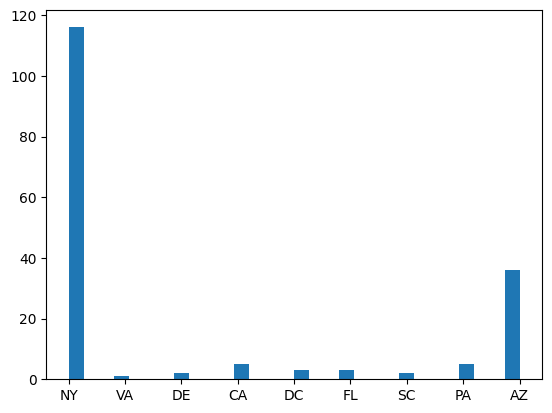

The plot above shows that the incidence of NY is much, much higher than the other states, with AZ a far second.  All of the other states will be heavily under represented if we use the data as is.  Techniques such as OHE will be needed in addition to upsampling to enhance the frequency of under represented states.  

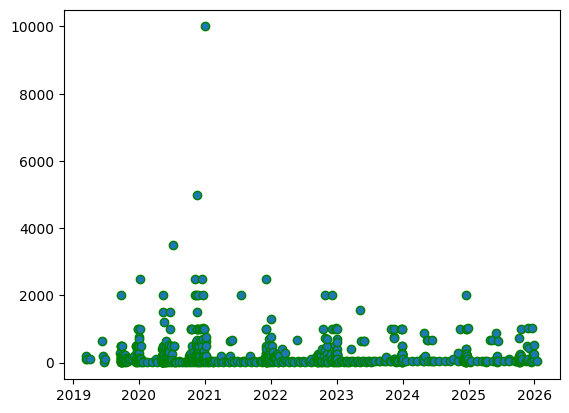

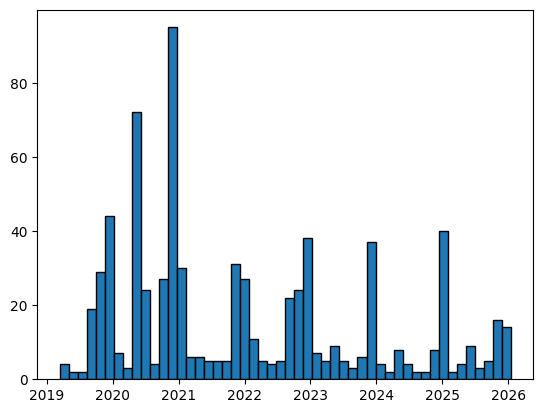

Looking at the scatter and histogram plots that we have created, it seems like there has been a decrease from the peak of donations at 2021.  This could perhaps be correlated to processes that have been discontinued/occurred only during 2021.  Perhaps this coincides with a significant event such as COVID for some reason.  Another insight retreived from these data is that the relative quantity of donations seems to peak around the end of the year.  

Text(0, 0.5, 'AMOUNT CHARGED')

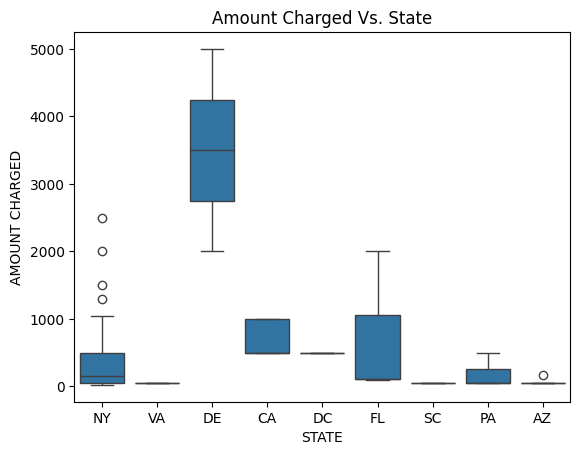

zip code
13905.0    47
85212.0    36
13903.0    19
13760.0    16
13850.0    11
13901.0     6
13744.0     6
13790.0     5
91326.0     5
12401.0     3
20007.0     3
18818.0     3
19904.0     2
13904.0     2
33477.0     2
29926.0     2
19143.0     2
23188.0     1
33950.0     1
13732.0     1
Name: count, dtype: int64

state_CA
0    168
1      5
Name: count, dtype: int64

state_DC
0    170
1      3
Name: count, dtype: int64

state_DE
0    171
1      2
Name: count, dtype: int64

state_FL
0    170
1      3
Name: count, dtype: int64

...

city_Philadelphia
0    171
1      2
Name: count, dtype: int64

city_Punta Gorda
0    172
1      1
Name: count, dtype: int64

city_Vestal
0    162
1     11
Name: count, dtype: int64

city_Washington
0    170
1      3
Name: count, dtype: int64

city_Williamsburg
0    172
1      1
Name: count, dtype: int64